# OCR Preprocessing — Registre de Commerce (v2)

Run cells top to bottom. Each function is isolated so you can re-run just one cell after tweaking a parameter, and inspect the image after every step.

**What changed from v1:**
- Replaced ineffective denoising/contrast steps with a **background-pattern removal** step — the actual fix for the wavy security texture (your old pipeline was fighting a structured pattern with tools built for random noise, and CLAHE was amplifying it).
- Added a **stroke-thinning** step for the bold Arabic font.
- Tuned CLAHE to be gentler, since background removal now does the heavy lifting.

In [1]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt

%matplotlib inline

input_path = "D:/stage Mobilis/OCR-registre-commerce/input/REGISTRE-FRONT.png" 
output_dir = "D:/stage Mobilis/OCR-registre-commerce/output/"

## 1. Load image
Reads the file into a NumPy array (BGR order — OpenCV's default, not RGB).

In [2]:
def load_image(path: str):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not read image at: {path}")
    return img

## 2. Upscale
Enlarges the image so text has enough pixels to be recognizable. `INTER_CUBIC` interpolation gives smooth edges instead of the blocky result you'd get from nearest-neighbor resizing.

In [3]:
def upscale(img, scale: float = 2.0):
    h, w = img.shape[:2]
    new_size = (int(w * scale), int(h * scale))
    return cv2.resize(img, new_size, interpolation=cv2.INTER_CUBIC)

## 3. Grayscale + watermark fade
Keeping only the **red channel** instead of a standard grayscale conversion: the orange "SPECIMEN" watermark is close to white in red intensity, so it nearly disappears here for free.

In [4]:
def to_grayscale_and_remove_watermark(img):
    b, g, r = cv2.split(img)
    return r

## 4. Remove background pattern (NEW — the key fix)

**What:** estimates the page's background (wavy texture + any lighting unevenness) and divides it out.

**Why:** your original pipeline tried to remove the wavy security-paper texture using denoising (built for small random noise) and contrast enhancement (which actually *amplified* the pattern's faint local contrast instead of hiding it). Neither tool targets a large-scale structured pattern — this function does.

**How:** a morphological **closing** with a large kernel fills in thin dark text with its lighter surroundings, producing an estimate of the page with no text on it — just the background. Dividing the real image by that estimate cancels the pattern out (background ÷ background ≈ white) while text, which isn't part of that estimate, stays dark.

`kernel_size` must be bigger than any stroke width but small enough not to erase fine graphic detail (QR code, logo) — this is the first parameter to tune if results look off.

In [5]:
def remove_background_pattern(gray, kernel_size=25):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    background = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)
    normalized = cv2.divide(gray, background, scale=255)
    return normalized

## 5. Denoise (changed: bilateral filter)
Now that the big pattern is handled upstream, this step only needs to mop up small residual noise. Bilateral filtering smooths flat areas while preserving sharp edges (character boundaries) — better suited to text than Non-Local Means, which tends to soften edges too.

In [6]:
def denoise(gray, d=9, sigma_color=75, sigma_space=75):
    return cv2.bilateralFilter(gray, d, sigma_color, sigma_space)

## 6. Enhance contrast (changed: gentler CLAHE)
Bigger tiles (16×16 vs 8×8) and a lower clip limit (2.0 vs 3.0) — less aggressive now that background normalization already flattened the page, avoiding the earlier over-amplification problem.

In [7]:
def enhance_contrast(gray, clip_limit=2.0, tile_size=16):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size, tile_size))
    return clahe.apply(gray)

## 7. Deskew (unchanged)
Detects rotation via the minimum-area bounding rectangle around all dark content, then rotates the image back straight.

In [8]:
def deskew(gray):
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    coords = np.column_stack(np.where(thresh > 0))
    if len(coords) == 0:
        return gray

    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    if abs(angle) < 0.5:
        return gray

    (h, w) = gray.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(gray, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

## 8. Binarize (unchanged)
Adaptive thresholding computes a local brightness cutoff per neighborhood rather than one global cutoff, since brightness can still vary slightly across the page.

In [9]:
def binarize(gray, block_size=25, C=15):
    return cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=block_size,
        C=C
    )

## 9. Full pipeline
Combines every step above and returns every intermediate stage, so you can inspect and compare them.

In [10]:
def preprocess_pipeline(path: str, scale: float = 2.0) -> dict:
    original            = load_image(path)
    upscaled            = upscale(original, scale=scale)
    gray                = to_grayscale_and_remove_watermark(upscaled)
    background_removed  = remove_background_pattern(gray)
    denoised            = denoise(background_removed)
    contrasted          = enhance_contrast(denoised)
    deskewed            = deskew(contrasted)
    binarized           = binarize(deskewed)

    return {
        "0_original": original,
        "1_upscaled": upscaled,
        "2_gray_no_watermark": gray,
        "3_background_removed": background_removed,
        "4_denoised": denoised,
        "5_contrasted": contrasted,
        "6_deskewed": deskewed,
        "7_binarized": binarized,
    }

## 10. Run it and look at the results

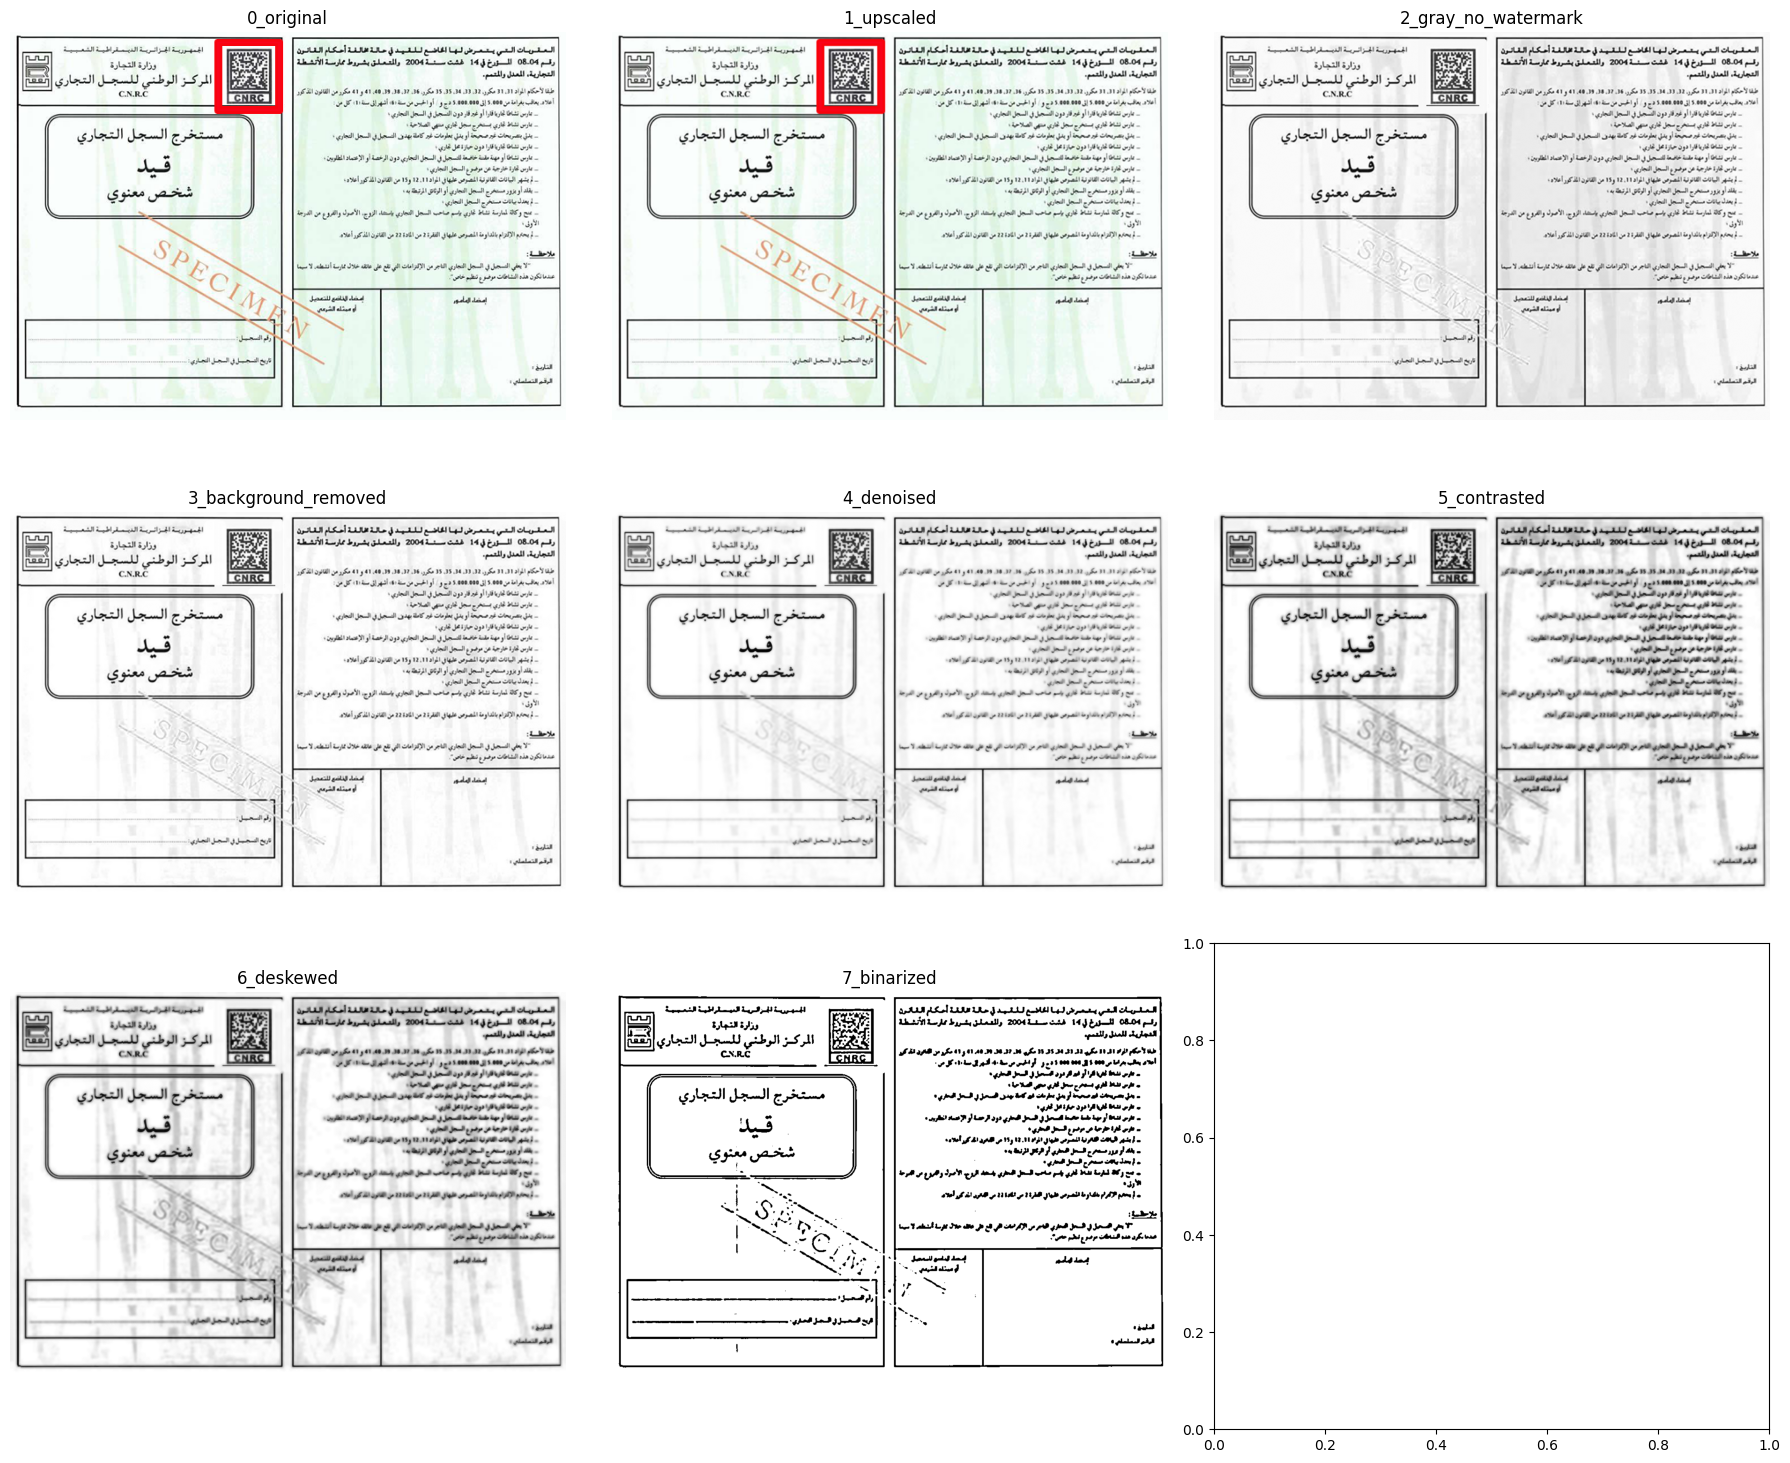

In [11]:
input_path = "D:/stage Mobilis/OCR-registre-commerce/input/REGISTRE-FRONT.png" 

results = preprocess_pipeline(input_path, scale=2.0)

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
for ax, (name, img) in zip(axes.flat, results.items()):
    if len(img.shape) == 3:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(img, cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 12. Save the final image (optional)

In [13]:
os.makedirs(output_dir, exist_ok=True)
cv2.imwrite(os.path.join(output_dir, "final_preprocessed.png"), results["7_binarized"])
print("Saved.")

Saved.


## Tuning tips

- **Pattern still shows through?** Increase `remove_background_pattern`'s `kernel_size` (try 31, 41...).
- **QR code / logo getting damaged or blurred?** Decrease `remove_background_pattern`'s `kernel_size` instead.
- **Text getting eaten away / too thin?** Reduce `thin_strokes`'s `kernel_size` to 1, or skip that step for fields where it hurts more than helps.
- **Always check the `7_binarized` stage first** when accuracy drops — it's the single step OCR quality depends on most.

## OCR

### Tesseract

In [14]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'


In [15]:
results = preprocess_pipeline(input_path, scale=2.0)
final_image = results["7_binarized"]

In [16]:
def ocr_with_confidence(image, psm, lang='ara+fra'):
    config = f'--oem 3 --psm {psm}'
    data = pytesseract.image_to_data(image, lang=lang, config=config, output_type=pytesseract.Output.DICT)
    confidences = [int(c) for c in data['conf'] if c != '-1']
    avg_conf = sum(confidences) / len(confidences) if confidences else 0
    text = pytesseract.image_to_string(image, lang=lang, config=config)
    return text, avg_conf


def extract_text_tesseract_best_psm(image, psm_list=(3, 4, 6, 11), lang='ara+fra'):
    best_text, best_conf, best_psm = "", -1, None
    for psm in psm_list:
        text, conf = ocr_with_confidence(image, psm, lang=lang)
        print(f"  psm {psm}: avg confidence = {conf:.1f}")
        if conf > best_conf:
            best_text, best_conf, best_psm = text, conf, psm
    print(f"-> Best: psm {best_psm} (confidence {best_conf:.1f})")
    return best_text

In [17]:
tesseract_text = extract_text_tesseract_best_psm(final_image)
tesseract_text 

  psm 3: avg confidence = 38.1
  psm 4: avg confidence = 38.1
  psm 6: avg confidence = 39.0
  psm 11: avg confidence = 28.7
-> Best: psm 6 (confidence 39.0)


'\u200epn e L AN\u200f لها للمانسع ليد \u200eJ\u200f حالة \u200eA\u200f القادرة — المسهررسة المزائرية البيسالرالمية الشمسمة\nرلم 08.04 السورخ لي14 008 2004110 والدمدن مشروط مارسة الأنشطة 7 £ وزارة التجارة %\nبي ناا المركز الوطني للسجل التجاري \u200eEZ\u200f\n\u200eUS\u200f لأحكم المرد ال 38 مكري قل 23 34 23 33 مكري \u200eE\u200f 27 34 39 40 41 و43 مكرر من \u200eUI SUS\u200f كير = ععمى\nولح يفا المسليسلفة \u200f أو اليس مر \u200een\u200f أشهر ال نسة :3 كال م +\nعارس نش أغر قرا لوقع اكز دون المسحمل في السعل التحاري ©\nم نقرس انشاط أأقري ترح \u200eu cu avd\u200f الصلاحي \u200eA ١\u200f\n= وملي بتصريحات قن صحيحة أو يدلي \u200ee r\u200f بي كام نهدن \u200eJ\u200f في السحلل التحاري \u200e٠\u200f مستحرج السجل التجاري\nم ترس \u200esp AN\u200f حبازة قل تغري \u200e١\u200f\n\u200f= تطرس \u200eé Tl\u200f نفس خط التسحل في السحل التحاري 238 \u200eu F\u200f الإ ماد الطقوبي \u200e٠\u200f - 0\nتقرس ترا حفرجيا عن موضوع السحل التحقري \u200e٠\u200f قد\n\u200ee\u200f / مشر \u200eN\u200f الفالرنية الممسرصض ع

### EasyOCR

In [18]:
import easyocr

def extract_text_easyocr(image):
    reader_ar = easyocr.Reader(['ar', 'en'], gpu=False)
    reader_fr = easyocr.Reader(['fr'], gpu=False)

    results_ar = reader_ar.readtext(image, detail=1)
    results_fr = reader_fr.readtext(image, detail=1)

    all_results = results_ar + results_fr
    all_results.sort(key=lambda r: r[0][0][1])  # sort top-to-bottom by y-coordinate

    lines = [f"{text}  (conf: {conf:.2f})" for (_, text, conf) in all_results]
    return "\n".join(lines)

In [ ]:
easyocr_text = extract_text_easyocr(final_image)
print(easyocr_text)

Using CPU. Note: This module is much faster with a GPU.


### PaddleOCR

In [ ]:
from paddleocr import PaddleOCR

def extract_text_paddleocr(image):
    ocr_ar = PaddleOCR(use_angle_cls=True, lang='ar')
    ocr_fr = PaddleOCR(use_angle_cls=True, lang='fr')

    result_ar = ocr_ar.ocr(image, cls=True)
    result_fr = ocr_fr.ocr(image, cls=True)

    lines = []
    for result in (result_ar, result_fr):
        if result and result[0]:
            for line in result[0]:
                text, conf = line[1]
                lines.append(f"{text}  (conf: {conf:.2f})")
    return "\n".join(lines)

In [ ]:
paddleocr_text = extract_text_paddleocr(final_image)
paddleocr_text 

### comparaison

In [ ]:
print("=== TESSERACT ===")
print(tesseract_text)
print("\n=== EASYOCR ===")
print(easyocr_text)
print("\n=== PADDLEOCR ===")
print(paddleocr_text)